# Week 08 – Text Classification using Machine Learning

This notebook builds a full text classification pipeline on the **Trump Tweet Sentiment Analysis** dataset.

### Pipeline Overview
1. Install & import libraries
2. Load the dataset
3. Text cleaning pipeline (helper functions from the preprocessing notebook)
4. Train / test split
5. TF-IDF vectorization
6. Model training & evaluation

## Step 0 – Mount Google Drive (Colab only)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 – Install & Import Required Libraries

In [2]:
# ── Core libraries ──────────────────────────────────────────────────────────
import re
import pandas as pd
import numpy as np

# ── NLTK ────────────────────────────────────────────────────────────────────
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ── Stop-word setup ──────────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
custom_stopwords = ['@', 'RT']
stop_words.update(custom_stopwords)

print('All libraries imported successfully!')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


All libraries imported successfully!


## Step 2 – Helper Functions for Text Cleaning

These are the same helper functions built in the Text Pre-processing notebook.
They are reproduced here so this notebook is fully self-contained.

In [19]:
# ── 2a. Lower-case ───────────────────────────────────────────────────────────
def lower_order(text):
    """Convert all characters in text to lower case."""
    return text.lower()


# ── 2b. Remove URLs ──────────────────────────────────────────────────────────
def remove_urls(text):
    """
    Remove URLs (http / https / www) from text using regex.
    Replaces matched URLs with an empty string.
    """
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)


# ── 2c. Remove emojis ────────────────────────────────────────────────────────
def remove_emoji(string):
    """
    Replace emojis and special Unicode symbols with a whitespace.
    Covers emoticons, symbols, pictographs, transport symbols and flags.
    """
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"   # emoticons
        u"\U0001F300-\U0001F5FF"   # symbols & pictographs
        u"\U0001F680-\U0001F6FF"   # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"   # flags (iOS)
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r' ', string)


# ── 2d. Remove unwanted characters ───────────────────────────────────────────
def removeunwanted_characters(document):
    """
    Remove @mentions, #hashtags, punctuation, emojis and extra spaces.
    Returns a clean, stripped string.
    """
    document = re.sub(r"@[A-Za-z0-9_]+", " ", document)   # @mentions
    document = re.sub(r"#[A-Za-z0-9_]+", "",  document)   # #hashtags
    document = re.sub(r"[^0-9A-Za-z ]", "",   document)   # non-alphanumeric
    document = remove_emoji(document)                        # any remaining emoji
    document = document.replace('  ', '')                    # double spaces
    return document.strip()


print('Helper functions defined.')

Helper functions defined.


## Step 3 – Build the Text Cleaning Pipeline

Combines all helper steps into one reusable function.
Supports both `"lemmatize"` (default) and `"stem"` modes.

In [5]:
def text_cleaning_pipeline(dataset, rule="lemmatize"):
    """
    Full text cleaning pipeline.

    Steps:
        1. Lowercase
        2. Remove URLs
        3. Remove emojis
        4. Remove mentions, hashtags, punctuation
        5. Tokenize (whitespace split)
        6. Remove stop-words
        7. Lemmatize  OR  Stem  (controlled by `rule`)

    Args:
        dataset (str): A single raw text string.
        rule    (str): 'lemmatize' (default) or 'stem'

    Returns:
        str: Cleaned, space-joined token string.
    """
    # 1. Convert to lower case
    data = lower_order(dataset)

    # 2. Remove URLs
    data = remove_urls(data)

    # 3. Remove emojis
    data = remove_emoji(data)

    # 4. Remove all other unwanted characters
    data = removeunwanted_characters(data)

    # 5. Tokenize
    tokens = data.split()

    # 6. Remove stop-words
    tokens = [word for word in tokens if word not in stop_words]

    # 7. Lemmatize or Stem
    if rule == "lemmatize":
        wordnet = WordNetLemmatizer()
        tokens = [wordnet.lemmatize(word, pos='v') for word in tokens]
    elif rule == "stem":
        porter = PorterStemmer()
        tokens = [porter.stem(word) for word in tokens]
    else:
        print("Pick between lemmatize or stem")

    return " ".join(tokens)


# Quick smoke-test
sample = "RT @JohnDoe: Check this out! https://t.co/abc #AI #ML 😎"
print("Original :" , sample)
print("Cleaned  :", text_cleaning_pipeline(sample))

Original : RT @JohnDoe: Check this out! https://t.co/abc #AI #ML 😎
Cleaned  : rt check


## Step 4 – Load the Dataset

Update the path below to match where `trump_tweet_sentiment_analysis.csv` is stored on your Drive.

In [6]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# Update the path below to match your Google Drive folder structure.
df = pd.read_csv(
    "/content/drive/MyDrive/AI_Sem6/trum_tweet_sentiment_analysis.csv",
    encoding="ISO-8859-1"
)

# Preview
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1850123, 2)


,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


In [8]:
print("Column names  :", df.columns.tolist())
print("Null values   :")
print(df.isnull().sum())
print("\nLabel distribution:")
print(df['Sentiment'].value_counts())   # adjust column name if needed (e.g. 'Sentiment')

Column names  : ['text', 'Sentiment']
Null values   :
text         0
Sentiment    0
dtype: int64

Label distribution:
Sentiment
0    1244211
1     605912
Name: count, dtype: int64


> **Note:** If your dataset uses a different column name for the label (e.g. `'Sentiment'` instead of `'label'`), update the references below accordingly.

## Step 5 – Apply Text Cleaning Pipeline

Apply `text_cleaning_pipeline` to every row in the `text` column.

In [10]:
# ── Drop rows where text or label is missing ──────────────────────────────────
df = df[['text', 'Sentiment']].dropna().reset_index(drop=True)

# ── Apply cleaning pipeline ───────────────────────────────────────────────────
print("Cleaning text... (may take a few seconds)")
df['cleaned_text'] = df['text'].apply(lambda x: text_cleaning_pipeline(str(x)))

# Preview first 5 cleaned entries
df[['text', 'cleaned_text', 'Sentiment']].head()

Cleaning text... (may take a few seconds)


,text,cleaned_text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,rtnot drain swamp taxpayer dollars trip advert...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,icymi hackers rig fm radio station play antitr...,0
2,Trump protests: LGBTQ rally in New York https:...,trump protest lgbtq rally new yorkbyvia,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",hi im piers morgan david beckham awful donald ...,0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,rt tech firm sue buzzfeed publish unverified t...,0


In [11]:
# ── Remove any rows where cleaning produced an empty string ───────────────────
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 1849957


## Step 6 – Train / Test Split

Split the cleaned dataset into **80 % training** and **20 % testing** sets.
`stratify=y` ensures both splits have the same class balance as the full dataset.

In [13]:
X = df['cleaned_text']   # features  (cleaned tweet text)
y = df['Sentiment']          # target    (sentiment label)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y           # preserves class distribution
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"\nTraining label distribution:\n{y_train.value_counts()}")

Training samples : 1479965
Testing  samples : 369992

Training label distribution:
Sentiment
0    995259
1    484706
Name: count, dtype: int64


## Step 7 – TF-IDF Vectorization

**TF-IDF** (Term Frequency – Inverse Document Frequency) converts raw text into
numerical feature vectors that machine learning models can consume.

- `max_features=5000` caps the vocabulary at the 5 000 most frequent terms to
  keep memory usage reasonable.
- We **fit** only on the training data to prevent data leakage, then **transform**
  both train and test.

In [14]:
# ── Initialise vectorizer ─────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=5000,   # top 5 000 terms
    ngram_range=(1, 2),  # unigrams + bigrams
    sublinear_tf=True    # apply log normalisation to term frequencies
)

# ── Fit on training data, transform both splits ───────────────────────────────
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Training matrix shape : {X_train_tfidf.shape}")
print(f"Testing  matrix shape : {X_test_tfidf.shape}")
print(f"Vocabulary size       : {len(tfidf.vocabulary_)}")

Training matrix shape : (1479965, 5000)
Testing  matrix shape : (369992, 5000)
Vocabulary size       : 5000


## Step 8 – Model Training: Logistic Regression

**Logistic Regression** is a strong baseline for text classification.
It learns a weight for every TF-IDF feature and outputs a probability for
each class.

In [15]:
# ── Train ─────────────────────────────────────────────────────────────────────
model = LogisticRegression(
    max_iter=1000,    # increase iterations to ensure convergence
    random_state=42,
    C=1.0             # regularisation strength (smaller = stronger regularisation)
)

model.fit(X_train_tfidf, y_train)
print("Model training complete!")

Model training complete!


## Step 9 – Model Evaluation

In [16]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test_tfidf)

# ── Accuracy ──────────────────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# ── Full classification report ────────────────────────────────────────────────
print("\nClassification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9063 (90.63%)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93    248815
           1       0.88      0.82      0.85    121177

    accuracy                           0.91    369992
   macro avg       0.90      0.89      0.89    369992
weighted avg       0.91      0.91      0.91    369992



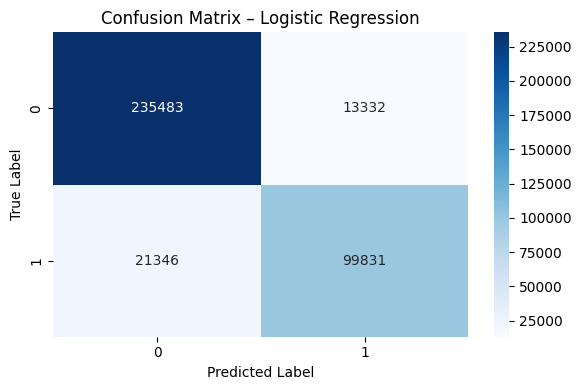

In [17]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

## Step 10 – Test on a Custom Tweet

Run the same pipeline on any new tweet string to see the model's prediction.

In [18]:
def predict_sentiment(tweet_text):
    """
    Clean a new tweet and return the predicted sentiment label.

    Args:
        tweet_text (str): Raw tweet string.

    Returns:
        Predicted label (int or str depending on dataset encoding).
    """
    cleaned  = text_cleaning_pipeline(tweet_text)
    features = tfidf.transform([cleaned])
    label    = model.predict(features)[0]
    proba    = model.predict_proba(features)[0]
    print(f"Tweet    : {tweet_text}")
    print(f"Cleaned  : {cleaned}")
    print(f"Predicted: {label}  |  Probabilities: {dict(zip(model.classes_, proba.round(3)))}")
    return label


# ── Try some examples ─────────────────────────────────────────────────────────
predict_sentiment("Trump is doing a great job for America! #MAGA")
print()
predict_sentiment("This administration is a complete disaster. #Resist")

Tweet    : Trump is doing a great job for America! #MAGA
Cleaned  : trump great job america
Predicted: 1  |  Probabilities: {np.int64(0): np.float64(0.18), np.int64(1): np.float64(0.82)}

Tweet    : This administration is a complete disaster. #Resist
Cleaned  : administration complete disaster
Predicted: 0  |  Probabilities: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(0.0)}


np.int64(0)